## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting? 
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Marin Marcillac

**Date:** 09/30/2026

In [ ]:
# Your Phase 1 solution to the problem goes here.


*QUESTIONS*
1. Regression helps predict a numeric outcome (continuous), like prices, while classification predicts a category label (discrete), like vehicle class.
2. A confusion matrix is a table that helps measure how well a classification model performs by comparing its predicted labels and the actual ground truth. A confusion matrix counts the predictions by the actual class and predicted class. Rows are the actual classes, and columns are the predictions. The model is correct along the diagonal, and its mistakes are the off-diagonal misclassifications.
3. This means the Sum of Squared Error. It is the sum of the squared differences between the observations and the group's mean. It helps quantify the total magnitude of prediction errors by summing the squared differences between the observations and the model's predicted values. A lower validation SSE means smaller error on the validation set.
4. Overfitting is when the model learns too much about the training data, so it includes noise, while underfitting means the model is too simple to see any real patterns.
5. Splitting the data helps us see how well a model generalizes to unseen data rather than just memorizing the training set. Evaluating candidates on a separate test set helps us select parameters like k that balance underfitting and overfitting. Like on the slide, we split the data to check predictions on new observations: fit models on a training set, compare predictions on a separate validation set, and keep a test set for final evaluation.
6. Class labels give a direct answer, but they hide how confident the model actually is. Probability distributions show the model's certainty and highlight messy spots near decision boundaries, but it takes extra time to get the final product.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv ("./data/land_mines.csv")
df.shape
df.head
df.info()
df.describe()
print("\nTarget Distribution")
print(df["mine_type"].value_counts().sort_index())

print("\nFeature")
display(df[['voltage', 'height', 'soil']].describe())
df.isnull().sum()
#data is cleaned

<class 'pandas.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   voltage    338 non-null    float64
 1   height     338 non-null    float64
 2   soil       338 non-null    float64
 3   mine_type  338 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 10.7 KB

Target Distribution
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64

Feature


,voltage,height,soil
count,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550
std,0.195819,0.306043,0.344244
min,0.197734,0.000000,0.000000
25%,0.309737,0.272727,0.200000
50%,0.359516,0.545455,0.600000
75%,0.482628,0.727273,0.800000
max,0.999999,1.000000,1.000000


voltage      0
height       0
soil         0
mine_type    0
dtype: int64

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
eval_X_raw = df[["voltage", "height", "soil"]]
eval_y = df["mine_type"]
(
eval_X_train_raw,
eval_X_valid_raw,
eval_y_train,
eval_y_valid,
) = train_test_split(
eval_X_raw, eval_y, test_size=0.50, random_state=25
)
eval_scaler = MinMaxScaler()
eval_X_train_scaled = eval_scaler.fit_transform(eval_X_train_raw)
eval_X_valid_scaled = eval_scaler.transform(eval_X_valid_raw)

In [3]:
from sklearn.neighbors import KNeighborsClassifier
eval_ks = np.arange(1, 51)
eval_valid_sse = []
eval_train_sse = []
for eval_k in eval_ks:
    eval_candidate = KNeighborsClassifier(n_neighbors=int(eval_k))
    eval_candidate.fit(eval_X_train_scaled, eval_y_train)
    eval_valid_hat = eval_candidate.predict(eval_X_valid_scaled)
    eval_train_hat = eval_candidate.predict(eval_X_train_scaled)
    eval_valid_sse.append(np.sum(
    (eval_y_valid.to_numpy() - eval_valid_hat) ** 2
    ))
    eval_train_sse.append(np.sum(
    (eval_y_train.to_numpy() - eval_train_hat) ** 2
    ))
    eval_k_star = int(eval_ks[np.argmin(eval_valid_sse)])

print(eval_k_star)

5


In [4]:
from sklearn.neighbors import KNeighborsClassifier

classification_model = KNeighborsClassifier(n_neighbors=5).fit(
    eval_X_train_scaled, eval_y_train
)

y_pred = classification_model.predict(eval_X_valid_scaled)
# I want a k value that doesn't overfit or underfit my data 
# (I can change it once I find the solution)
print(y_pred)


[1 2 3 5 4 1 5 1 2 3 2 3 1 1 3 1 4 3 2 4 5 3 1 1 3 3 3 4 3 1 5 2 3 1 2 4 1
 5 1 3 1 5 5 3 3 5 1 3 2 2 1 1 4 3 4 2 3 4 1 3 3 4 1 3 2 1 3 2 2 2 4 3 2 3
 2 5 1 3 5 1 5 2 3 4 4 1 2 4 2 3 4 5 1 4 2 2 4 4 3 3 1 5 1 2 1 1 1 4 3 1 2
 2 2 1 3 1 4 2 3 4 1 4 2 1 4 1 5 3 3 1 1 1 2 3 3 3 2 2 3 1 4 1 2 5 2 3 1 1
 5 3 3 1 4 2 5 1 1 2 4 5 1 1 3 2 2 5 3 3 1]


[[24  0 11  5  3]
 [ 0 24  1  3  0]
 [ 8  2 10  6  5]
 [ 7  4 14  2  6]
 [ 8  5  7  9  5]]


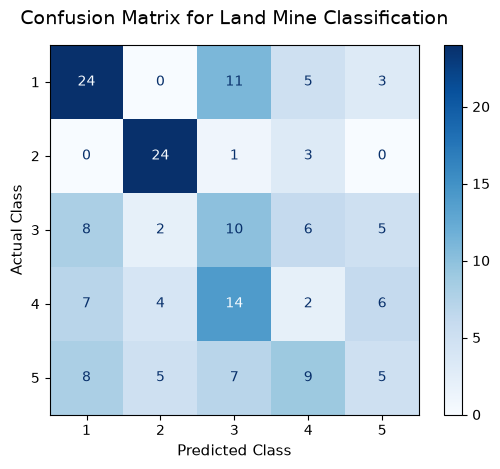

In [5]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = classification_model.predict(eval_X_valid_scaled)

classes = [1, 2, 3, 4, 5]

cm = confusion_matrix(eval_y_valid, y_pred, labels=classes)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Land Mine Classification", fontsize=14, pad=15)
plt.xlabel("Predicted Class", fontsize=11)
plt.ylabel("Actual Class", fontsize=11)
plt.show()

#I use the information froom here: https://www.geeksforgeeks.org/machine-learning/how-to-plot-confusion-matrix-with-labels-in-sklearn/
#https://www.geeksforgeeks.org/machine-learning/confusion-matrix-machine-learning/

In [18]:
#4 The overall accuracy is 37.79% because we sum the diagonal 
# cells (the correct predictions: 23+31+12+9+3=65
# and divide by the total number of validation samples (172. 
# in the lecture slides, diagonal cells count correct 
# predictions, while off-diagonal cells count misclassifications.








The model's overall accuracy is pretty low at just 38.5%, meaning it struggles with most of the dataset. It does a solid job identifying Class 1 and is decent with Class 0, but it completely falls apart on Classes 3 and 4. 

5.According to the slides, k-NN is kind of risky to use by itself for land mine removal. Even if it seems accurate, it has abrupt boundaries and doesn't tell you why it's making a certain call. Also choosing a k can overfits the noise, but too big underfits the patterns. Because of that, we definitely shouldn't use it to make final decisions. It should just act as a first tool. 

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]